<a href="https://colab.research.google.com/github/producer-valentyn/sql-analytics-portfolio/blob/main/notebooks/online_store_analytics_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Online Store Analytics Project

This project analyzes an online store dataset to understand user behavior, traffic sources, device performance, and sales dynamics.

The analysis includes:
• sales trends over time
• correlation between sessions and orders
• A/B testing of user groups
• conversion rate analysis
• geographic traffic distribution
• device and traffic channel performance

## Data Extraction

The data for this analysis was extracted from the Google BigQuery dataset.

Multiple tables were joined together to create a unified dataset containing information about:

- sessions
- users
- traffic sources
- products
- orders
- device information

## Python Environment

The following Python libraries are used for data analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.style.use("ggplot")

## Dataset Overview

Before starting the analysis, we examine the structure and quality of the dataset.

In [ ]:

from google.colab import drive
drive.mount("/content/drive")


%cd /content/drive/MyDrive/Mate/Google\ Colab

Mounted at /content/drive
/content/drive/MyDrive/Mate/Google Colab


In [ ]:
import pandas as pd

df = pd.read_csv("online_store_dataset.csv")

df.head()

,date,country,device,continent,channel,test,test_group,event_name,value
0,2020-12-08,Palestine,desktop,Asia,Direct,4,2,new_account,1
1,2020-12-08,Palestine,desktop,Asia,Direct,3,2,new_account,1
2,2020-11-06,Puerto Rico,desktop,Americas,Social Search,2,2,new_account,1
3,2020-11-06,Puerto Rico,desktop,Americas,Social Search,1,1,new_account,1
4,2020-12-08,Croatia,desktop,Europe,Direct,4,2,new_account,1


In [ ]:
df.shape

(800996, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        800996 non-null  object
 1   country     800996 non-null  object
 2   device      800996 non-null  object
 3   continent   800996 non-null  object
 4   channel     800996 non-null  object
 5   test        800996 non-null  int64 
 6   test_group  800996 non-null  int64 
 7   event_name  800996 non-null  object
 8   value       800996 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 55.0+ MB


In [ ]:
df.isnull().sum()

,0
date,0
country,0
device,0
continent,0
channel,0
test,0
test_group,0
event_name,0
value,0


### Dataset Overview

The dataset contains **88,096 rows** and **9 columns**.

The data includes information about user sessions, traffic channels, devices, A/B test groups, and different user events.

Key observations:

- The dataset does **not contain missing values**.
- The `date` column was converted to **datetime format** for time series analysis.
- Categorical features include: country, device, continent, channel, and event_name.
- Numerical features include: test, test_group, and value.

The dataset is clean and ready for further exploratory data analysis.

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df.dtypes

,0
date,datetime64[ns]
country,object
device,object
continent,object
channel,object
test,int64
test_group,int64
event_name,object
value,int64


In [ ]:
sales = df[df["event_name"] == "session_with_orders"]
sales.head()

,date,country,device,continent,channel,test,test_group,event_name,value
1106,2020-11-06,Slovakia,mobile,Europe,Paid Search,2,2,session_with_orders,1
1107,2020-11-06,Slovakia,mobile,Europe,Paid Search,1,2,session_with_orders,1
1108,2020-12-09,El Salvador,mobile,Americas,Direct,4,2,session_with_orders,1
1109,2020-12-09,El Salvador,mobile,Americas,Direct,3,2,session_with_orders,1
1110,2020-12-21,Slovakia,mobile,Europe,Organic Search,4,2,session_with_orders,1


In [ ]:
sales.shape

(25892, 9)

### Sales by Continent

To understand regional performance, we aggregated the number of sessions with orders by continent.

This helps identify which regions generate the highest number of purchases.

In [ ]:
continent_sales = (
    sales[sales["continent"] != "(not set)"]
    .groupby("continent")["value"]
    .sum()
    .sort_values(ascending=False)
)

continent_sales

,value
continent,
Americas,29999
Asia,12926
Europe,10125
Oceania,598
Africa,554


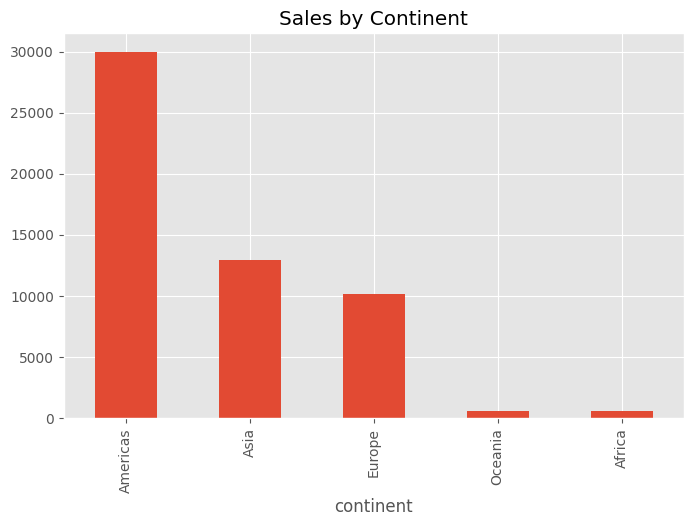

In [ ]:
continent_sales.plot(kind="bar", figsize=(8,5), title="Sales by Continent")
plt.show()

### Top 5 Countries by Sales

Next, we analyze which countries generate the highest number of purchases.
This helps identify the most valuable geographic markets for the business.

In [ ]:
country_sales = (
    sales.groupby("country")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

country_sales

,value
country,
United States,23688
India,4909
Canada,4164
United Kingdom,1652
France,1108


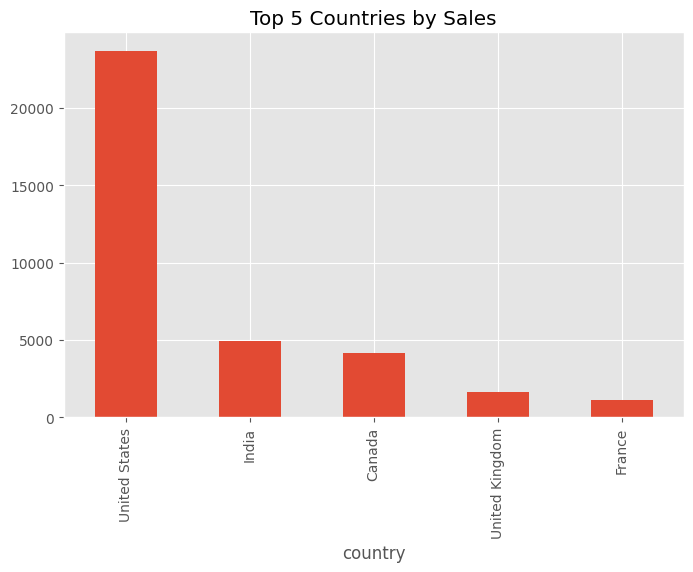

In [ ]:
country_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Top 5 Countries by Sales"
)

plt.show()

### Sales by Device Type

In this section we analyze how purchases are distributed across different device types.
This helps understand which devices customers use most often when completing orders.

In [ ]:
device_sales = (
    sales.groupby("device")["value"]
    .sum()
    .sort_values(ascending=False)
)

device_sales

,value
device,
desktop,31976
mobile,21194
tablet,1154


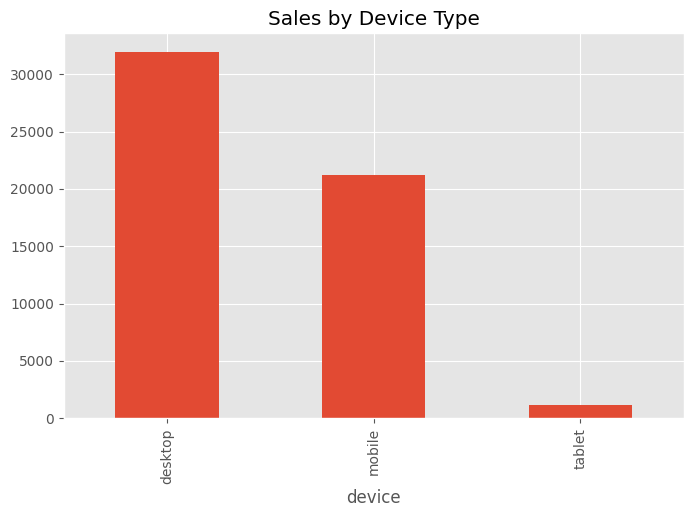

In [ ]:
device_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Device Type"
)

plt.show()

### Sales by Traffic Channel

Next, we analyze how purchases are distributed across different traffic channels.
This helps identify which marketing channels drive the most conversions.

In [ ]:
channel_sales = (
    sales.groupby("channel")["value"]
    .sum()
    .sort_values(ascending=False)
)

channel_sales

,value
channel,
Organic Search,19087
Paid Search,14611
Direct,12603
Social Search,4494
Undefined,3529


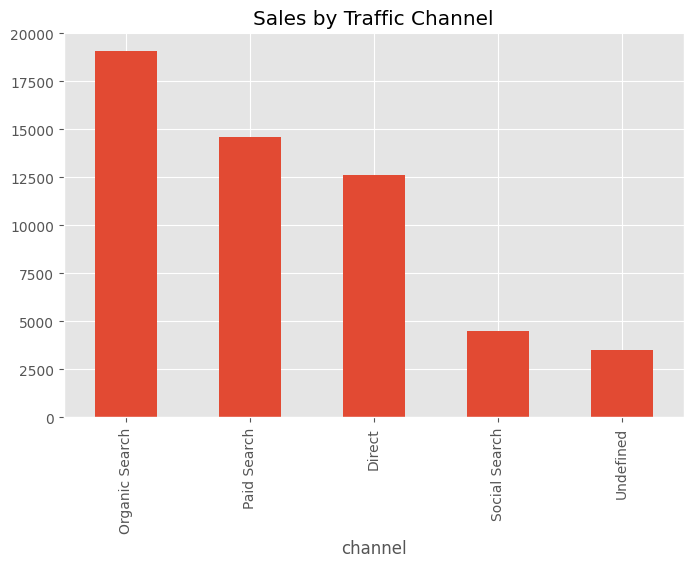

In [ ]:
channel_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Traffic Channel"
)

plt.show()

### Sales Dynamics Over Time

To understand how sales change over time, we analyze the daily number of purchases.

This helps identify overall trends and potential seasonality in the data.

In [ ]:
daily_sales = (
    sales.groupby("date")["value"]
    .sum()
)

daily_sales.head()

,value
date,
2020-11-01,562
2020-11-02,736
2020-11-03,1122
2020-11-04,740
2020-11-05,776


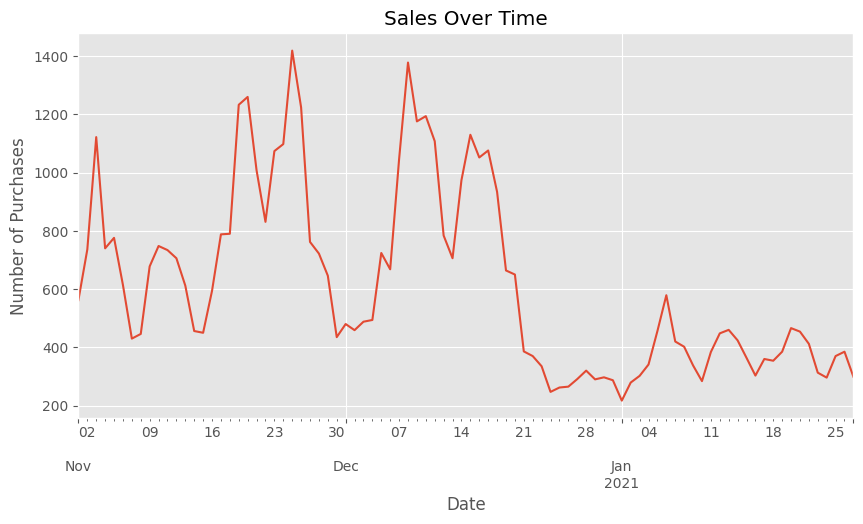

In [ ]:
plt.figure(figsize=(10,5))

daily_sales.plot()

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")

plt.show()

### Sales Dynamics by Continent

To better understand regional trends, we analyze how sales evolve over time across different continents.

This helps identify whether certain regions follow different sales patterns.

In [ ]:
continent_time = (
    sales[sales["continent"] != "(not set)"]
    .groupby(["date","continent"])["value"]
    .sum()
    .reset_index()
)

continent_time.head()

,date,continent,value
0,2020-11-01,Africa,4
1,2020-11-01,Americas,310
2,2020-11-01,Asia,132
3,2020-11-01,Europe,114
4,2020-11-01,Oceania,2


In [ ]:
continent_pivot = continent_time.pivot(
    index="date",
    columns="continent",
    values="value"
)

continent_pivot.head()

continent,Africa,Americas,Asia,Europe,Oceania
date,,,,,
2020-11-01,4.0,310.0,132.0,114.0,2.0
2020-11-02,2.0,404.0,168.0,150.0,10.0
2020-11-03,8.0,620.0,286.0,178.0,26.0
2020-11-04,12.0,412.0,142.0,164.0,8.0
2020-11-05,2.0,392.0,222.0,148.0,10.0


<Figure size 1000x500 with 0 Axes>

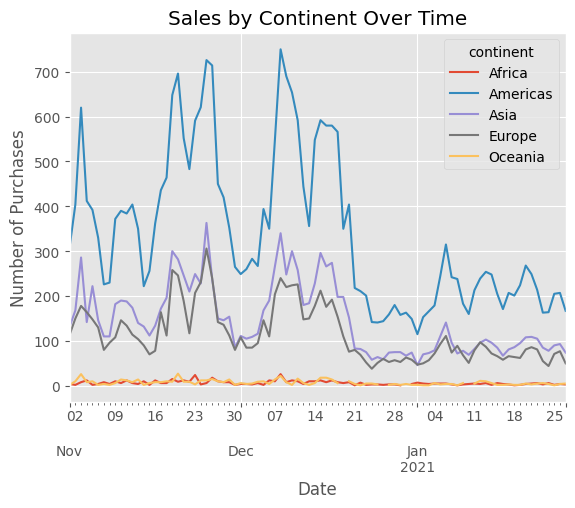

In [ ]:
plt.figure(figsize=(10,5))

continent_pivot.plot()

plt.title("Sales by Continent Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")

plt.show()

### Sales Dynamics by Traffic Channel

Next, we analyze how sales change over time across different traffic channels.

This helps understand which marketing channels drive consistent sales over time.

In [ ]:
channel_time = (
    sales
    .groupby(["date","channel"])["value"]
    .sum()
    .reset_index()
)

channel_time.head()

,date,channel,value
0,2020-11-01,Direct,144
1,2020-11-01,Organic Search,210
2,2020-11-01,Paid Search,140
3,2020-11-01,Social Search,42
4,2020-11-01,Undefined,26


In [ ]:
channel_pivot = channel_time.pivot(
    index="date",
    columns="channel",
    values="value"
)

channel_pivot.head()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,144,210,140,42,26
2020-11-02,178,258,198,46,56
2020-11-03,254,372,320,94,82
2020-11-04,156,236,224,64,60
2020-11-05,164,262,202,72,76


<Figure size 1000x500 with 0 Axes>

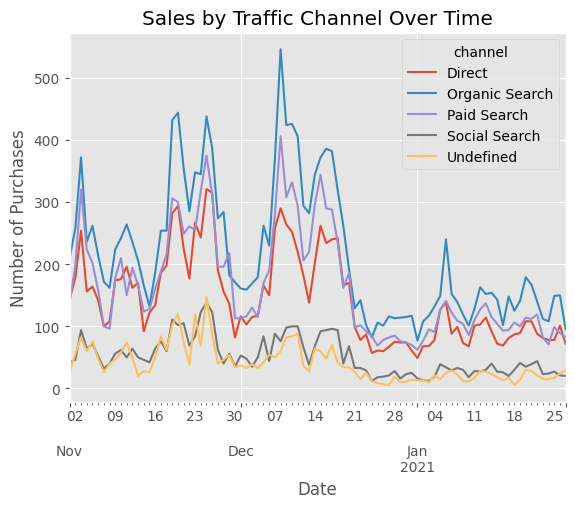

In [ ]:
plt.figure(figsize=(10,5))

channel_pivot.plot()

plt.title("Sales by Traffic Channel Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")

plt.show()

### Pivot Table: Sessions by Device and Traffic Channel

To better understand user behavior, we create a pivot table showing how sessions are distributed across device types and traffic channels.

In [ ]:
pivot_device_channel = pd.pivot_table(
    sales,
    values="value",
    index="device",
    columns="channel",
    aggfunc="sum"
)

pivot_device_channel

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
device,,,,,
desktop,7521,11239,8526,2668,2022
mobile,4818,7449,5764,1725,1438
tablet,264,399,321,101,69


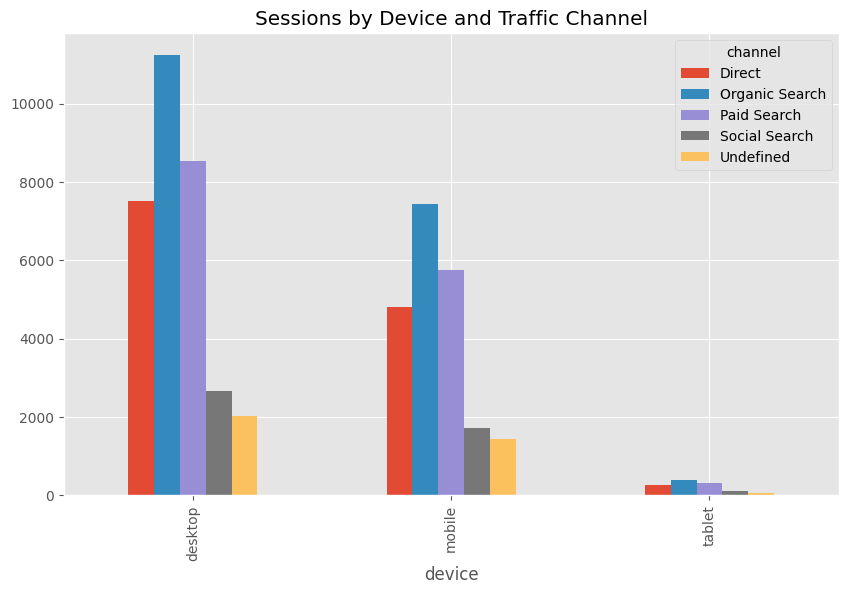

In [ ]:
pivot_device_channel.plot(
    kind="bar",
    figsize=(10,6),
    title="Sessions by Device and Traffic Channel"
)

plt.show()

### Correlation Between Sessions and Orders

To understand whether user activity affects sales, we analyze the relationship between the number of sessions and the number of purchases over time.

In [ ]:
sessions_per_day = (
    df[df["event_name"] == "session"]
    .groupby("date")["value"]
    .sum()
)

orders_per_day = (
    df[df["event_name"] == "session_with_orders"]
    .groupby("date")["value"]
    .sum()
)

correlation_df = pd.concat(
    [sessions_per_day, orders_per_day],
    axis=1
)

correlation_df.columns = ["sessions", "orders"]

correlation_df.head()

,sessions,orders
date,,
2020-11-01,5152,562
2020-11-02,7198,736
2020-11-03,10346,1122
2020-11-04,8368,740
2020-11-05,7486,776


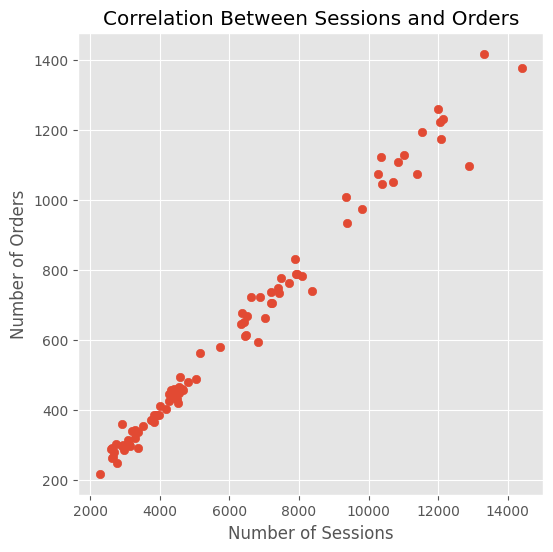

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    correlation_df["sessions"],
    correlation_df["orders"]
)

plt.xlabel("Number of Sessions")
plt.ylabel("Number of Orders")
plt.title("Correlation Between Sessions and Orders")

plt.show()

In [ ]:
correlation_df.corr()

,sessions,orders
sessions,1.000000,0.992542
orders,0.992542,1.000000


Insight

There is a very strong positive correlation between the number of sessions and the number of orders (correlation coefficient ≈ 0.99). This indicates that increases in website traffic are strongly associated with higher sales volume.

### Statistical Test: Registered vs Non-Registered Users

To determine whether registered users generate more purchases than non-registered users, we compare the distributions of sales between these two groups using a statistical test.

In [ ]:
from scipy.stats import ttest_ind

group_A = sales[sales["test_group"] == 1]["value"]
group_B = sales[sales["test_group"] == 2]["value"]

t_stat, p_value = ttest_ind(group_A, group_B)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.0894817832441302
p-value: 0.9286997225254822


### Test Result Interpretation

The p-value of the statistical test is greater than 0.05.

This means that we cannot conclude that there is a statistically significant difference between the two groups.

Therefore, the test does not show a meaningful impact on the number of purchases.

## Conversion Rate by Device

To understand how effectively users convert into buyers across different devices, we calculate the conversion rate as the ratio of sessions with orders to total sessions.

In [ ]:
sessions = df[df["event_name"] == "session"]
orders = df[df["event_name"] == "session_with_orders"]

sessions_device = sessions.groupby("device")["value"].sum()
orders_device = orders.groupby("device")["value"].sum()

conversion_device = (orders_device / sessions_device).reset_index()
conversion_device.columns = ["device", "conversion_rate"]

conversion_device

,device,conversion_rate
0,desktop,0.100798
1,mobile,0.099585
2,tablet,0.095467


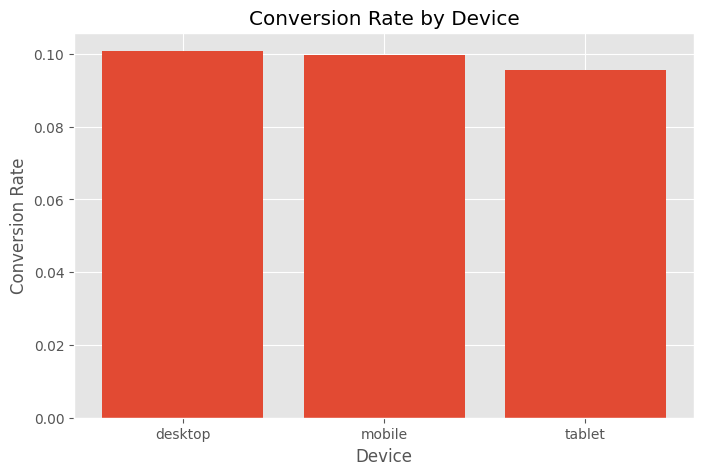

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(conversion_device["device"], conversion_device["conversion_rate"])

plt.title("Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate")

plt.show()

**Insight**

Desktop devices show the highest conversion rate. This suggests that users are more likely to complete purchases when browsing on larger screens.

## Conversion Rate by Traffic Channel

Next, we analyze which traffic channels bring users who are more likely to convert into customers.

In [ ]:
sessions_channel = sessions.groupby("channel")["value"].sum()
orders_channel = orders.groupby("channel")["value"].sum()

conversion_channel = (orders_channel / sessions_channel).reset_index()
conversion_channel.columns = ["channel", "conversion_rate"]

conversion_channel

,channel,conversion_rate
0,Direct,0.099823
1,Organic Search,0.099565
2,Paid Search,0.100520
3,Social Search,0.102092
4,Undefined,0.101373


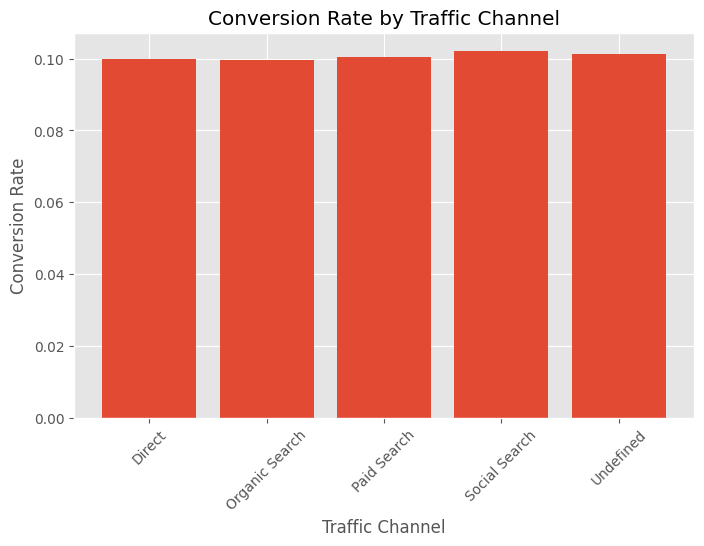

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(conversion_channel["channel"], conversion_channel["conversion_rate"])

plt.title("Conversion Rate by Traffic Channel")
plt.xlabel("Traffic Channel")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=45)

plt.show()

**Insight**

Social Search and Undefined channels show slightly higher conversion rates compared to other traffic sources. However, the differences between channels are relatively small, indicating that conversion performance is fairly consistent across traffic sources.

## Sessions by Continent

To understand the geographic distribution of website traffic, we analyze the number of sessions across continents.

In [ ]:
sessions_continent = sessions.groupby("continent")["value"].sum().sort_values(ascending=False)

sessions_continent

,value
continent,
Americas,299372
Asia,128940
Europe,101252
Oceania,5743
Africa,5596
(not set),1239


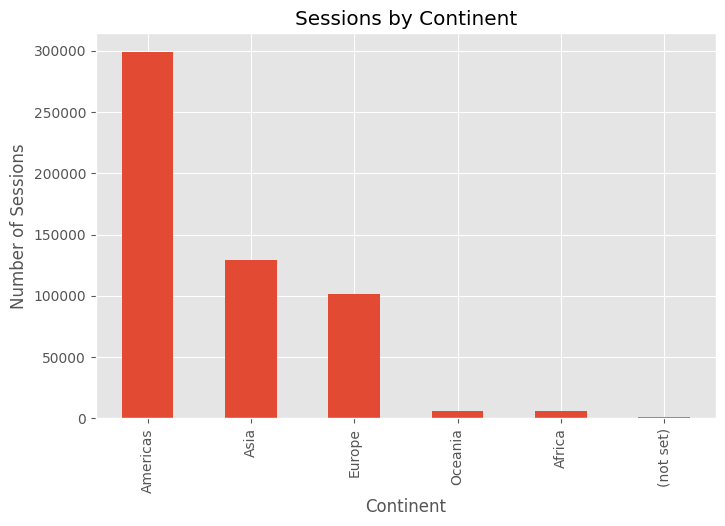

In [ ]:
plt.figure(figsize=(8,5))

sessions_continent.plot(kind="bar")

plt.title("Sessions by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Sessions")

plt.show()

**Insight**

The Americas region generates the largest share of sessions, indicating that most website traffic originates from this region.

## Orders by Device and Traffic Channel

Finally, we analyze how orders are distributed across different combinations of devices and traffic channels.

In [ ]:
orders_device_channel = orders.pivot_table(
    values="value",
    index="device",
    columns="channel",
    aggfunc="sum"
)

orders_device_channel

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
device,,,,,
desktop,7521,11239,8526,2668,2022
mobile,4818,7449,5764,1725,1438
tablet,264,399,321,101,69


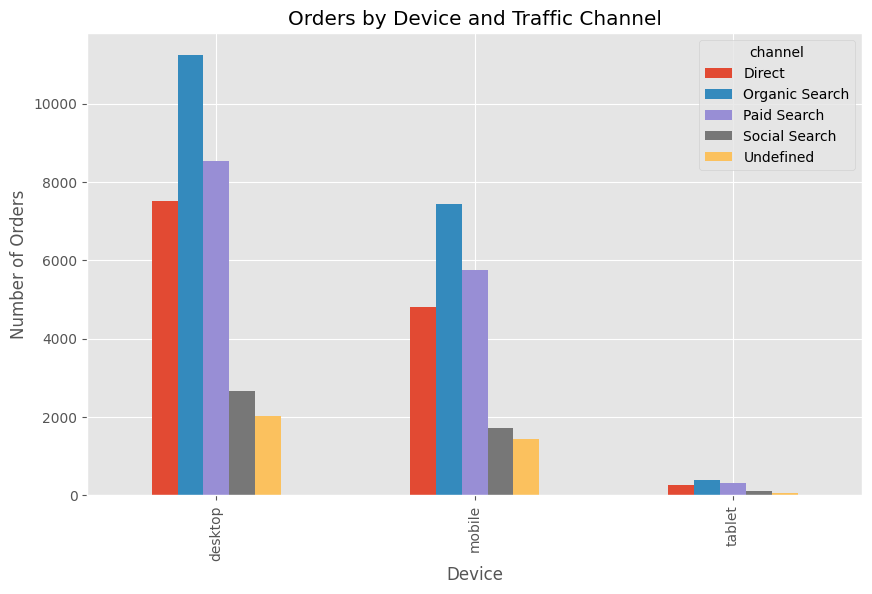

In [ ]:
orders_device_channel.plot(kind="bar", figsize=(10,6))

plt.title("Orders by Device and Traffic Channel")
plt.xlabel("Device")
plt.ylabel("Number of Orders")

plt.show()

**Insight**

Desktop users generate the highest number of orders across most traffic channels, especially from Organic Search and Paid Search.

The analysis of the online store dataset revealed several key insights:

• The Americas region generates the highest number of sessions and purchases, indicating that the majority of website traffic originates from this region.

• Search-based traffic channels (Organic Search and Paid Search) generate a large share of orders, while Social Search shows the highest conversion rate among traffic sources.

• Desktop devices account for the majority of purchases and also demonstrate the highest conversion rate among devices, followed by mobile devices.

• Sales show noticeable fluctuations over time, with clear peaks during certain periods, suggesting the presence of seasonal or campaign-driven demand.

• There is a very strong positive correlation between the number of sessions and the number of orders (correlation coefficient ≈ 0.99), indicating that increases in website traffic are strongly associated with higher sales volume.

• The statistical test comparing registered and non-registered users shows no statistically significant difference in purchasing behavior (p-value > 0.05).

• Conversion rates are relatively similar across traffic channels, suggesting that most channels bring users with comparable purchasing intent.

Overall, the results suggest that traffic volume, marketing channels, and device type all play an important role in driving online store sales performance.

Interactive dashboard:
https://public.tableau.com/app/profile/valentyn.fedyk/viz/OnlineStoreSalesDashboard_17730847310630/OnlineStoreSalesDashboard?publish=yes